<a href="https://colab.research.google.com/github/jatinm17/Churn-Modeling/blob/main/ANN_IMPLEMENTATION_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.15.0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
dataset=pd.read_csv("Churn_Modelling.csv")

In [ ]:
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# dividing the dataset into dependent and independent features
X=dataset.iloc[:,3:13]
y=dataset.iloc[:,13]

In [ ]:
# dependent features
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [ ]:
# independent features
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

In [ ]:
# creating dummy variables
geography=pd.get_dummies(X['Geography'],drop_first=True)
geography

,Germany,Spain
0,False,False
1,False,True
2,False,False
3,False,False
4,False,True
...,...,...
9995,False,False
9996,False,False
9997,False,False
9998,True,False


In [ ]:
gender=pd.get_dummies(X['Gender'],drop_first=True)
gender

,Male
0,False
1,False
2,False
3,False
4,False
...,...
9995,True
9996,True
9997,False
9998,True


In [ ]:
# concate with dataframe
X=pd.concat([X,geography,gender],axis=1)


In [ ]:
# drop unneccessary columns
X=X.drop(['Geography','Gender'],axis=1)

In [ ]:
# training and test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)


In [ ]:
# feature scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

**CREATING AN ANN MODEL**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU
from tensorflow.keras.layers import Dropout

In [ ]:
# intialising ANN
classifier=Sequential()


In [ ]:
# adding first hidden layer
classifier.add(Dense(units=11,activation='relu'))
# second
classifier.add(Dense(units=6,activation='relu'))
# third
classifier.add(Dense(units=1,activation='relu'))

In [ ]:
classifier.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
model_history=classifier.fit(X_train,y_train,validation_split=0.33,batch_size=10,epochs=50)

Epoch 1/50
536/536 [==============================] - 3s 3ms/step - loss: 0.4781 - accuracy: 0.8024 - val_loss: 0.4435 - val_accuracy: 0.8050
Epoch 2/50
536/536 [==============================] - 1s 3ms/step - loss: 0.4148 - accuracy: 0.8205 - val_loss: 0.4249 - val_accuracy: 0.8179
Epoch 3/50
536/536 [==============================] - 1s 3ms/step - loss: 0.3928 - accuracy: 0.8397 - val_loss: 0.4108 - val_accuracy: 0.8228
Epoch 4/50
536/536 [==============================] - 1s 3ms/step - loss: 0.3770 - accuracy: 0.8431 - val_loss: 0.4018 - val_accuracy: 0.8289
Epoch 5/50
536/536 [==============================] - 2s 4ms/step - loss: 0.3694 - accuracy: 0.8474 - val_loss: 0.3945 - val_accuracy: 0.8376
Epoch 6/50
536/536 [==============================] - 2s 4ms/step - loss: 0.3623 - accuracy: 0.8530 - val_loss: 0.3928 - val_accuracy: 0.8406
Epoch 7/50
536/536 [==============================] - 2s 3ms/step - loss: 0.3686 - accuracy: 0.8535 - val_loss: 0.3923 - val_accuracy: 0.8436
Epoch 

In [ ]:
# list all data in history
print(model_history.history.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


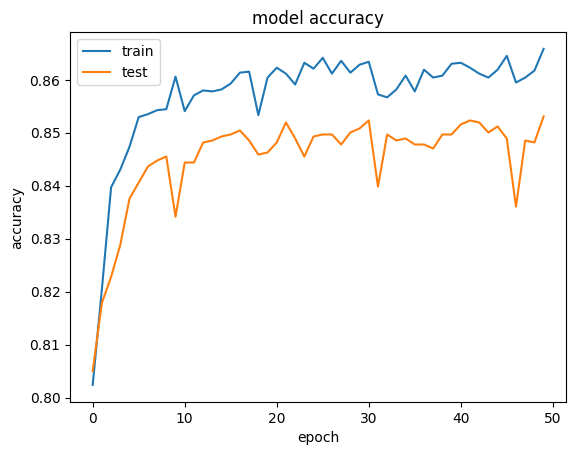

In [ ]:
# summarize history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

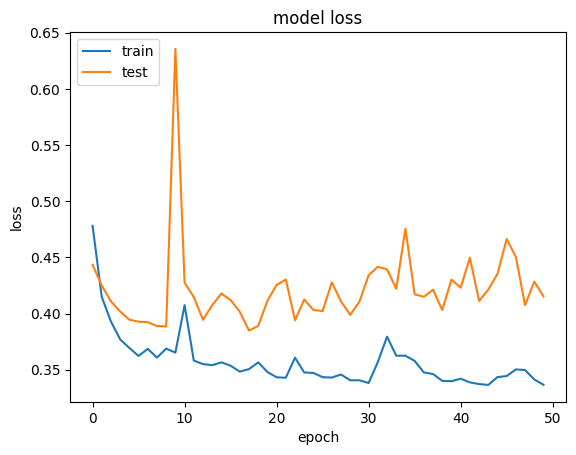

In [ ]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [ ]:
# Predicting the Test set results
y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.5)

63/63 [==============================] - 0s 3ms/step


In [ ]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[1501,   94],
       [ 195,  210]])

In [ ]:
# Calculate the Accuracy
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_test)

In [ ]:
score

0.8555